# Flood Risk Prediction

# FLOOD RISK PREDICTION

## 1.Problem Definition
Flooding is one of the most devastating natural disasters, often resulting in loss of life, displacement, and destruction of property and infrastructure. Accurate and timely flood risk prediction is critical for disaster preparedness, urban planning, and climate resilience efforts. 

### Statistics
On average, floods affect at least 45,000 people annually, with some years seeing hundreds of thousands displaced. 

Deaths:
Floods have caused at least 480 deaths in recent years. In 2021, they accounted for 39% of disaster-related deaths. 

In May 2024, floods affected 39,185 people in 14 districts within 11 days.  
In November 2019, floods and landslides in Bundibugyo, Bududa, and Sironko districts resulted in at least 38 deaths and over 150 injuries, affecting an estimated 300,000 people, according to ReliefWeb.  
In April 2023, floods and landslides in Kasese, Mbale, and Rukungiri districts resulted in multiple deaths and displacement.  
In November 2023, the Uganda Red Cross Society reported 25,000 people already affected by floods and anticipated further impacts due to the El Niño period, according to Anticipation Hub. 

### Mbarara in Specific
 A notable instance occurred in March 2018 when a heavy downpour caused the Rwizi River to overflow, resulting in at least one death and damage to buildings, including a hotel under construction. 
 More recently, in May 2023, heavy rains disrupted business activities and submerged the NWSC system after the Rwizi River breached its banks, according to The Cooperator News.


## Solution
A machine learning-powered flood risk prediction system that estimates the probability of flooding in a given region based on 20+ environmental, climatic, and infrastructural indicators. By transforming complex data into real-time flood probability scores and risk categories, the model empowers governments, city planners, and disaster management teams to make data-driven decisions that minimize flood impact, enhance early warning systems, and protect vulnerable communities."


**What we shall do:**
- Problem Definition & Motivation
- Data Cleaning & Preprocessing
- Feature Engineering & Selection
- Exploratory Data Analysis (EDA) with visualizations
- Model Selection & Baseline Comparisons
- Model Training, Evaluation, and Interpretation

In [ ]:
# ## 1. Imports & Environment Setup
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pycaret.regression import *
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lars
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Problem Definition

**Objective:** Build a regression model to predict flood probability in a region.  

**Why Regression?**  
- Directly quantifies flood-driving volume.  
- Enables threshold-based classification for flood alerts.  
- Simpler and more interpretable than direct classification on limited data.  

**Target:** `FloodPrediction` that is in continous form.  

**Features** 
- MonsoonIntensity
- TopographyDrainage
- RiverManagement
- Deforestation
- Urbanization
- ClimateChange
- DamsQuality
- Siltation
- AgriculturalPractices
- Encroachments
- IneffectiveDisasterPreparedness
- DrainageSystems
- CoastalVulnerability
- Landslides
- Watersheds
- DeterioratingInfrastructure
- PopulationScore
- WetlandLoss
- InadequatePlanning
- PoliticalFactors

## 3. Data Acquisition, Cleaning and Preprocessing

We managed to acquire a dataset from kaggle.com with sufficient information to train our model. It seemed well processed already but we decided to have our own take on it, for the sake of research and understanding the underlying principles of handling datasets for ML.

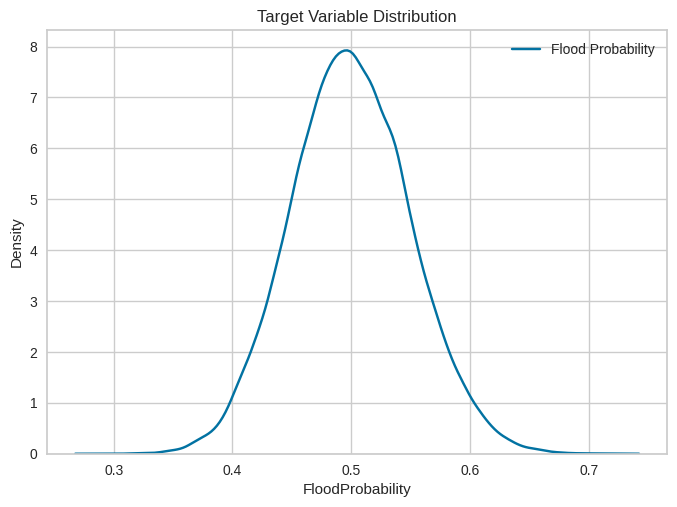

In [2]:
df = pd.read_csv('data/flood.csv')

# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Check for class imbalance in target (though continuous)
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.legend(['Flood Probability'])
plt.show()

In [ ]:
import smogn

# Ensure all columns are float32 for compatibility and efficiency with smogn
df = df.astype('float32')

relevance_config = np.array([
    [0.4, 1.0, 0.5],
    [0.5, 0.0, 0.5],
    [0.6, 1.0, 0.5]
])

# 2. Apply SMOGN with custom relevance
df_smogn = smogn.smoter(
    data=df,
    y='FloodProbability',
    rel_thres=0.8,
    rel_method='manual',
    rel_ctrl_pts_rg=relevance_config,
    samp_method='extreme',
    k=3
)

print("Original shape:", df.shape)
print("SMOGN-balanced shape:", df_smogn.shape)

# Use the new dataframe for training
df = df_smogn.copy()

sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.show()

### 4. Feature Engineering and Selection

In [3]:
# 1. Interaction terms (domain knowledge-based)
df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']
df['Urbanization_Encroachment'] = df['Urbanization'] * df['Encroachments']

# 2. Climate vulnerability index
climate_features = ['ClimateChange', 'CoastalVulnerability', 'WetlandLoss']
df['ClimateVulnerability'] = df[climate_features].mean(axis=1)

# 3. Infrastructure quality composite
infra_features = ['RiverManagement', 'DamsQuality', 'DrainageSystems']
df['InfrastructureQuality'] = df[infra_features].mean(axis=1)

X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Exploratory Data Analysis (EDA)

Let's visualize:
1. Basic Summary Statistics
2. Missing Values Check
3. Distribution Plots
4. Correlation Matrix
5. Pairplots / Scatterplots
Focused on top-correlated features with FloodProbability
Helps visually identify linear/nonlinear trends
6. Boxplots
Show how each feature influences FloodProbability
Detect outliers (e.g., via IQR)

Dataset Description:

       MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
count      50000.000000        50000.000000      50000.00000   50000.000000   
mean           4.991480            4.984100          5.01594       5.008480   
std            2.236834            2.246488          2.23131       2.222743   
min            0.000000            0.000000          0.00000       0.000000   
25%            3.000000            3.000000          3.00000       3.000000   
50%            5.000000            5.000000          5.00000       5.000000   
75%            6.000000            6.000000          6.00000       6.000000   
max           16.000000           18.000000         16.00000      17.000000   

       Urbanization  ClimateChange  DamsQuality     Siltation  \
count  50000.000000   50000.000000  50000.00000  50000.000000   
mean       4.989060       4.988340      5.01536      4.988600   
std        2.243159       2.226761      2.24500      2.232642   
min   

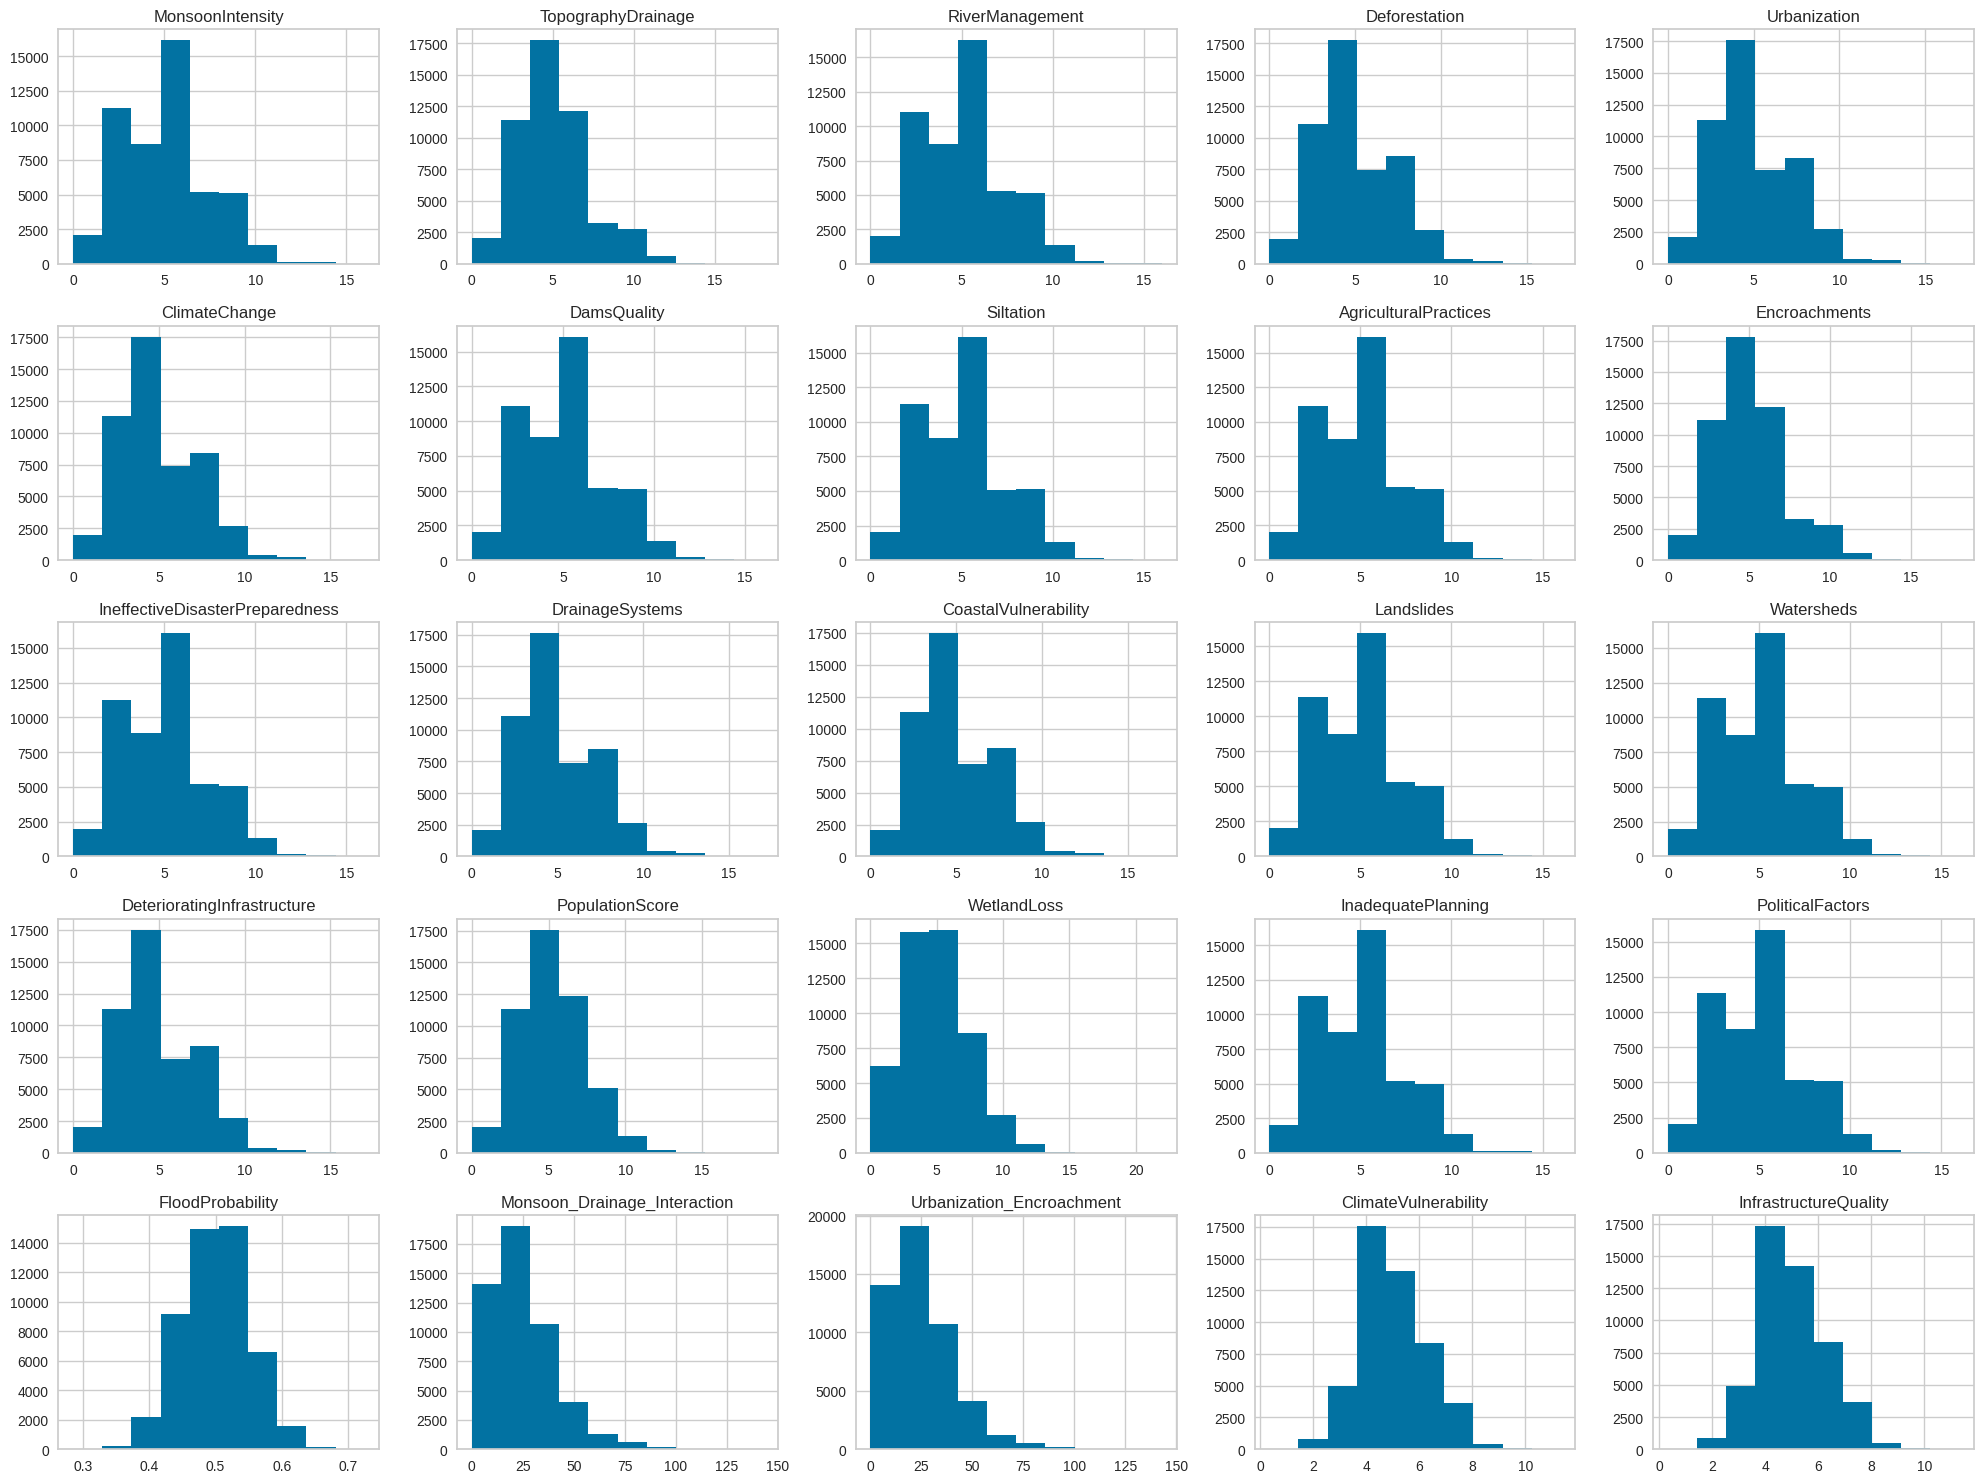

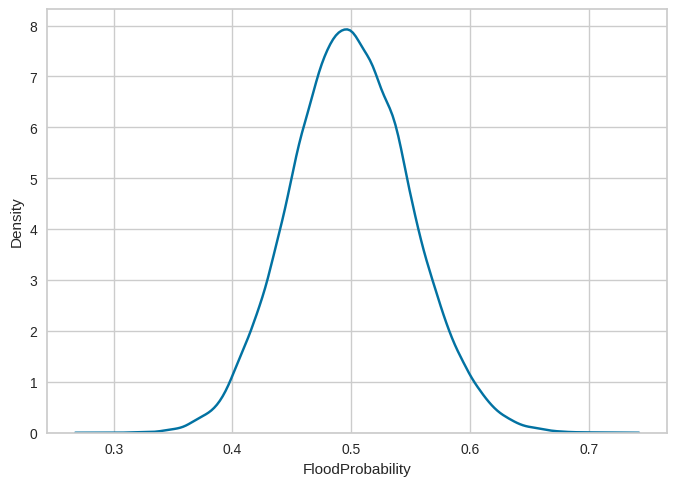

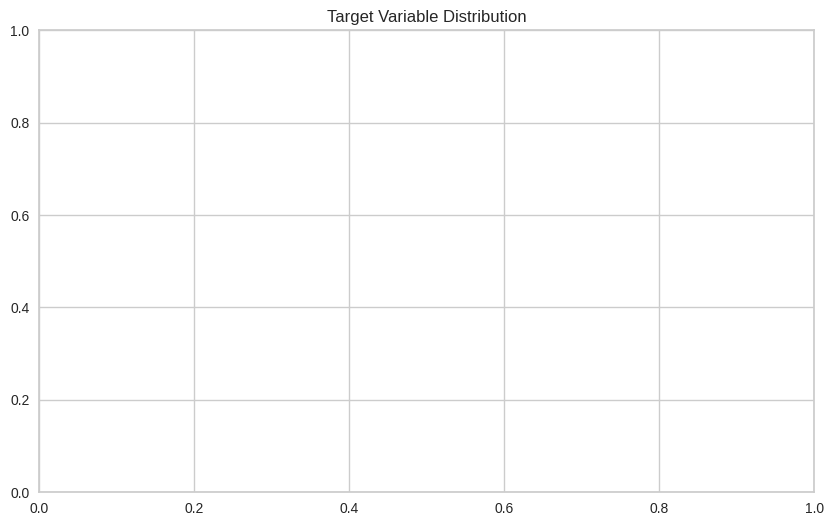

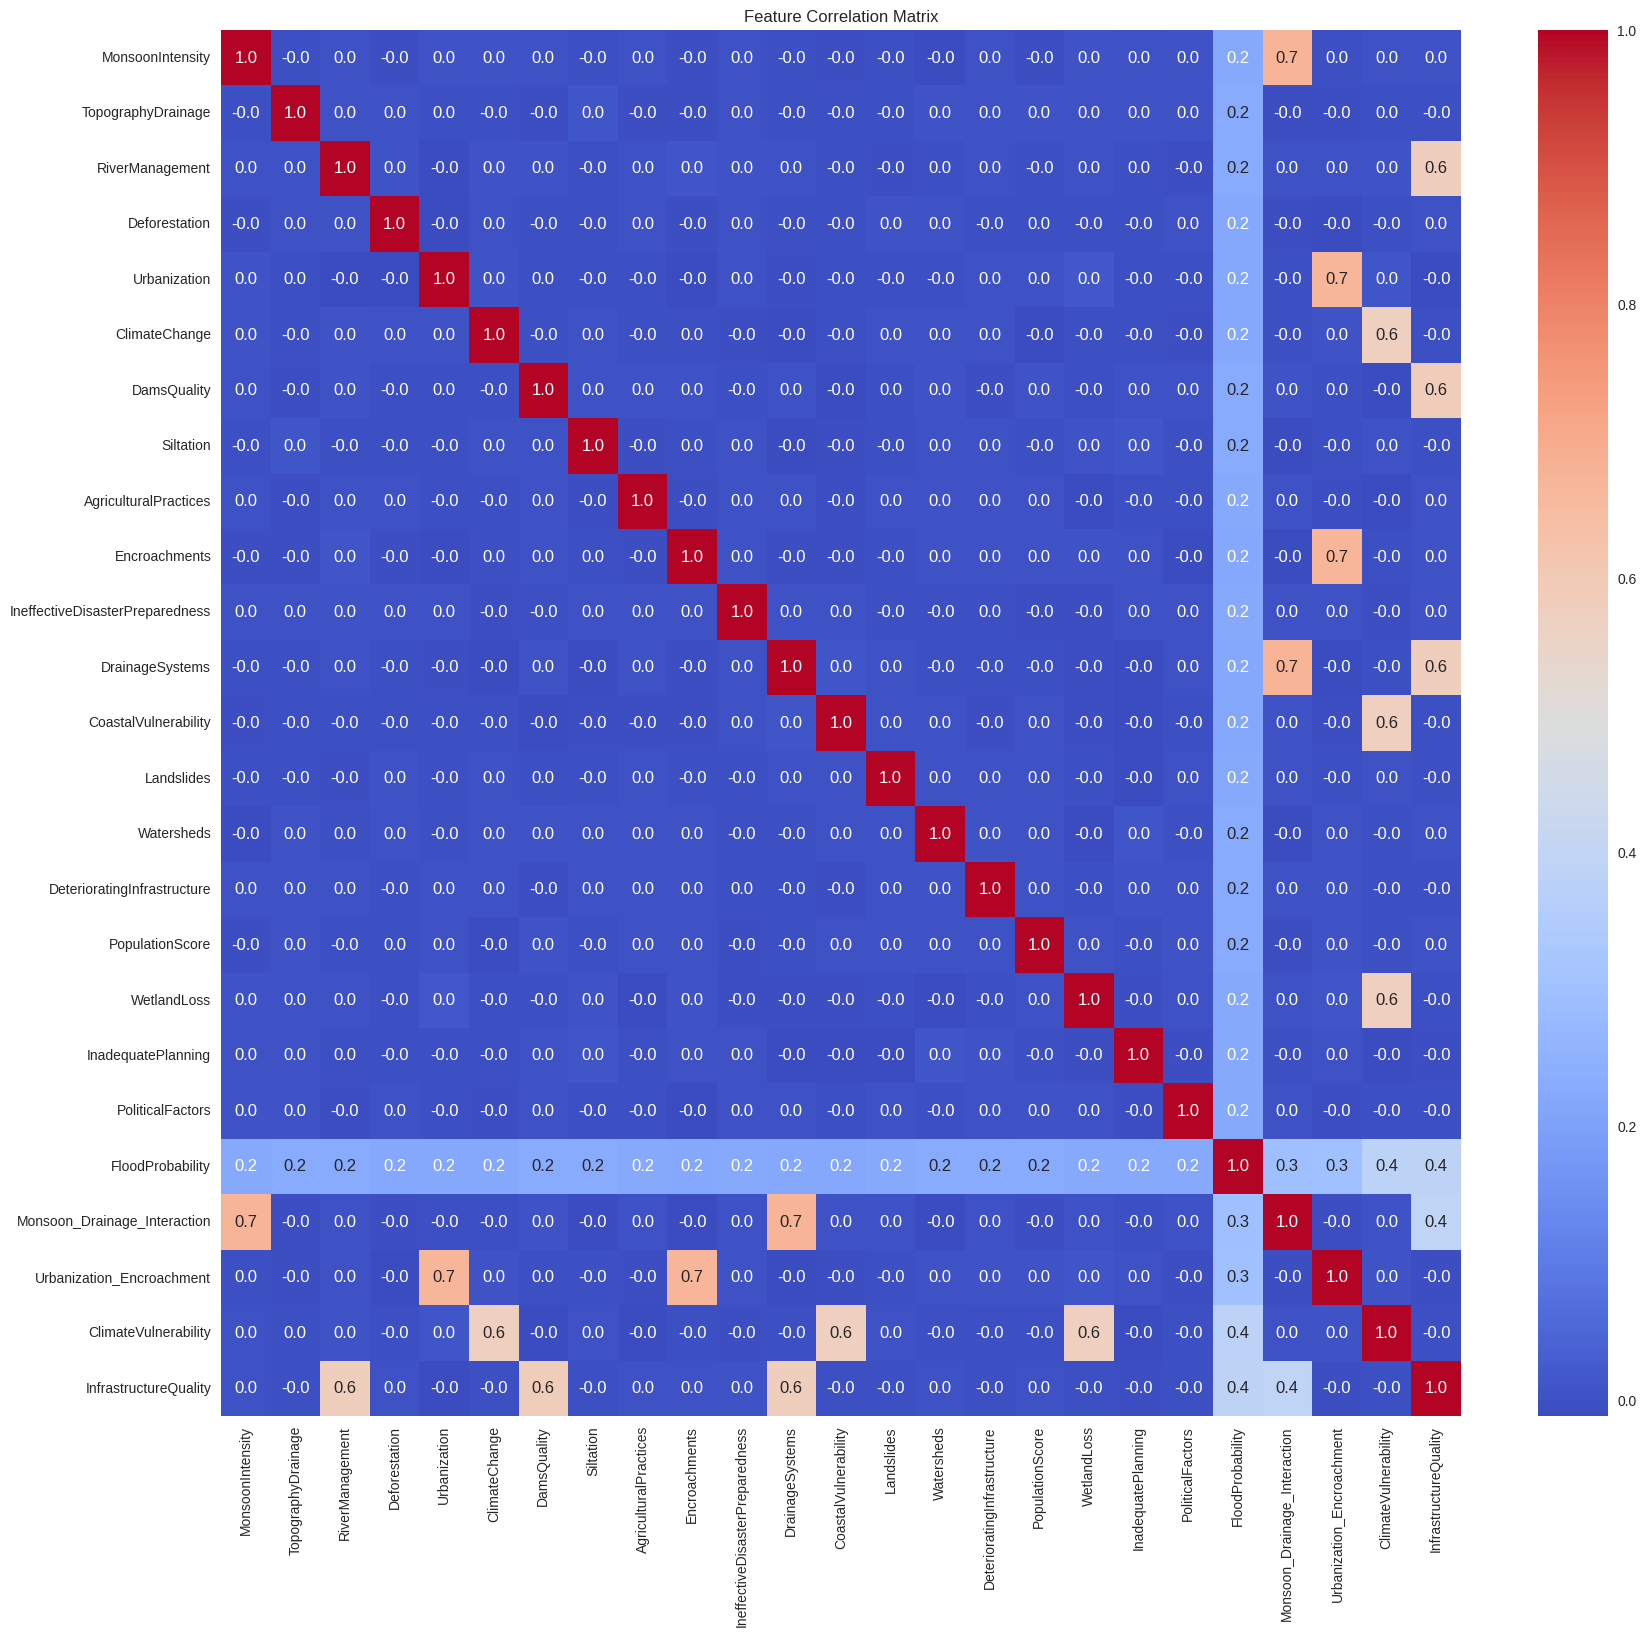

Top features by correlation:
 FloodProbability                1.000000
InfrastructureQuality           0.387482
ClimateVulnerability            0.382139
Urbanization_Encroachment       0.297995
Monsoon_Drainage_Interaction    0.296578
DeterioratingInfrastructure     0.229444
TopographyDrainage              0.229414
RiverManagement                 0.228917
Watersheds                      0.228152
DamsQuality                     0.227467
Name: FloodProbability, dtype: float64


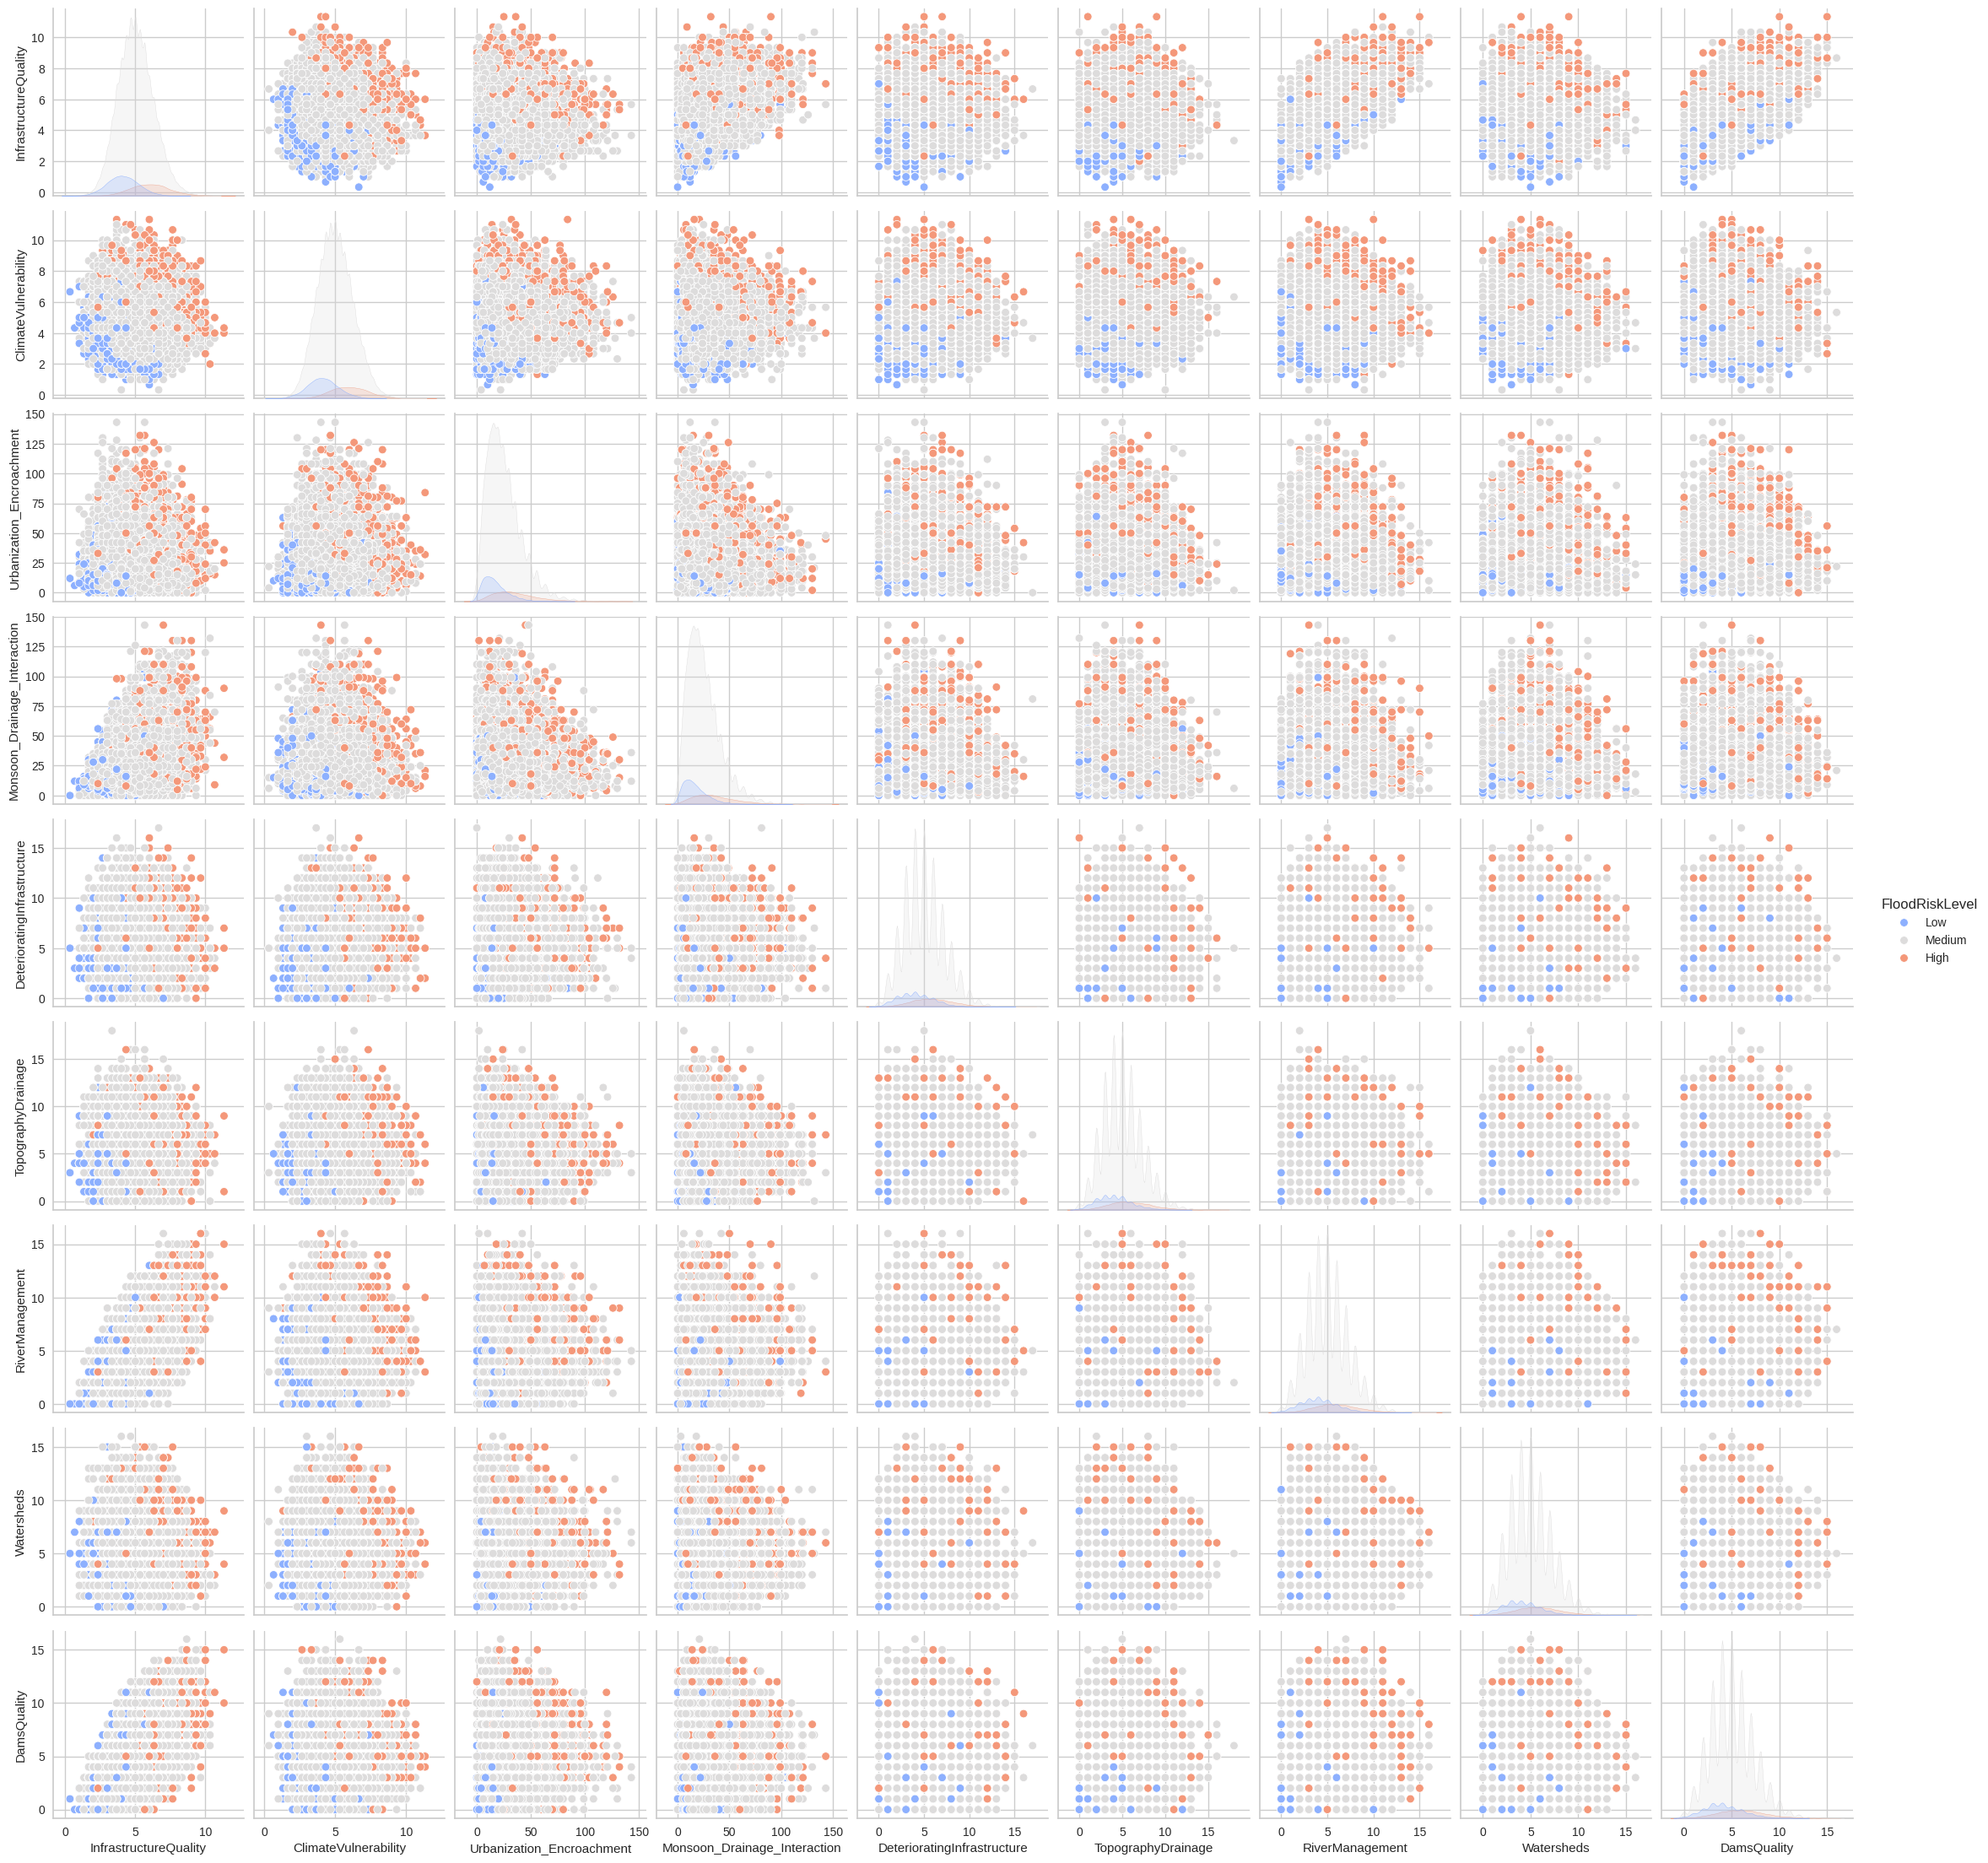

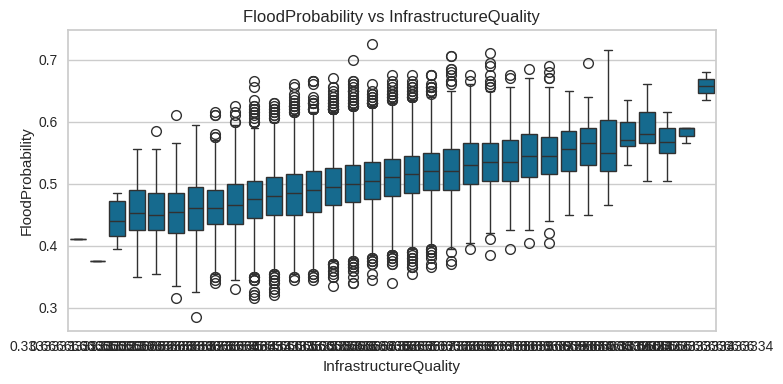

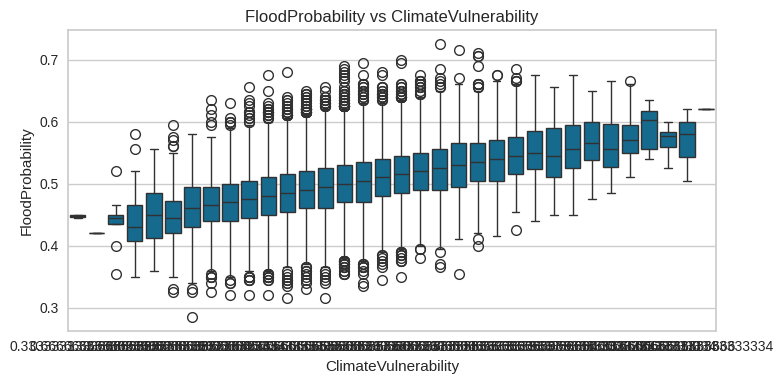

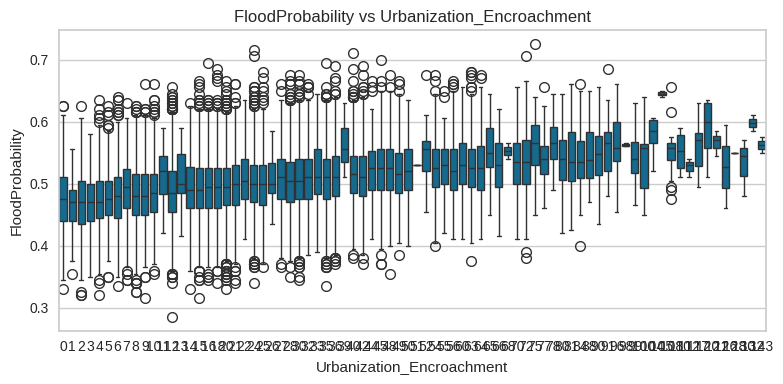

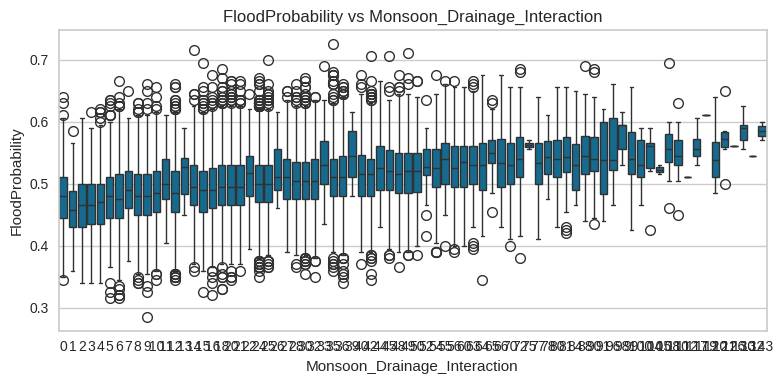

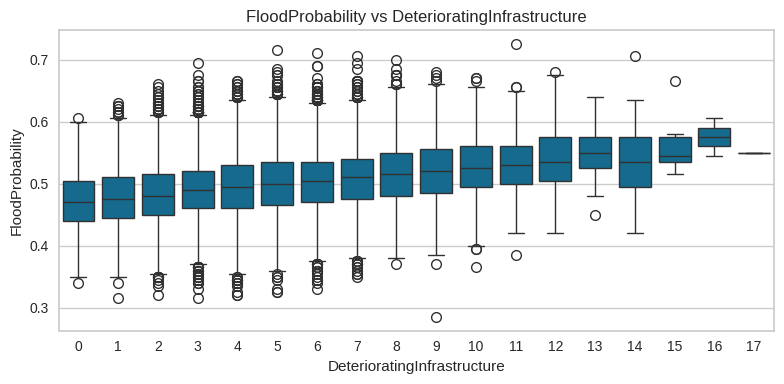

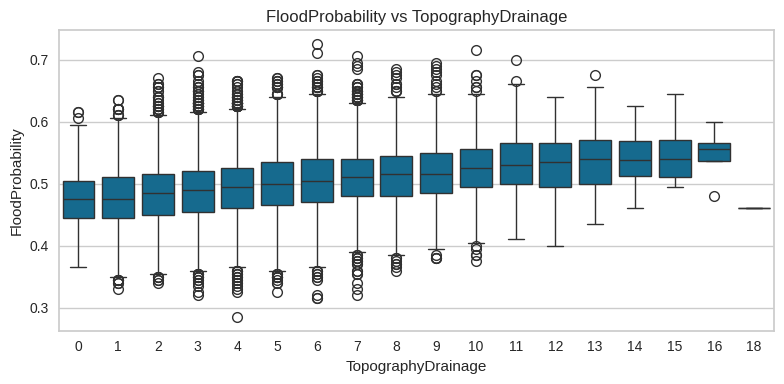

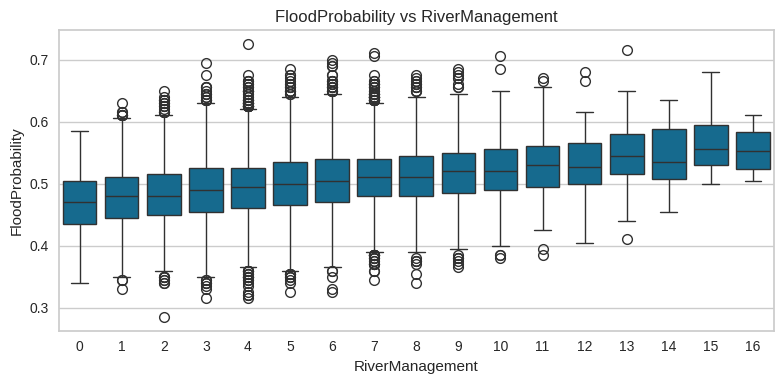

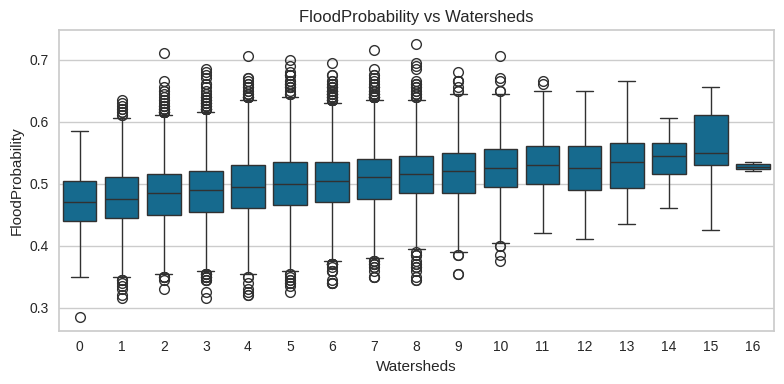

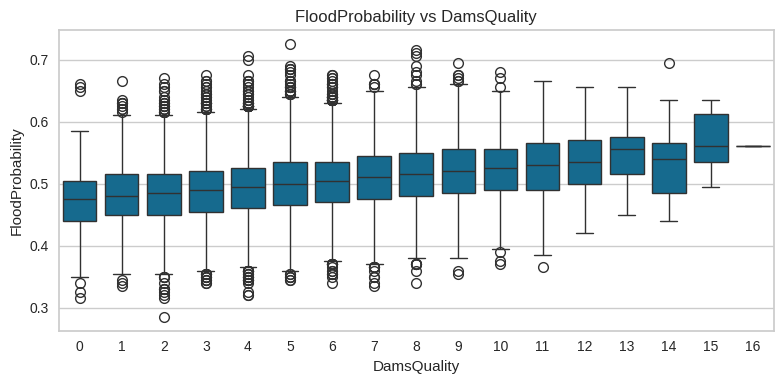

In [4]:
print("Dataset Description:\n")
#print(df.info())
print(df.describe())

# Check missing values
print("MISSING VALUES:\n", df.isnull().sum())

# Verify feature distributions
df.hist(figsize=(20, 15), bins=10)
plt.tight_layout()
plt.show()

# Visualize sampled target variable distribution
sns.kdeplot(df['FloodProbability'])
plt.figure(figsize=(10, 6))
plt.title('Target Variable Distribution')
plt.legend(['Flood Probability'])
plt.show()

# ====== CORRELATION ANALYSIS ======
plt.figure(figsize=(20, 18))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

target_corr = corr_matrix['FloodProbability'].abs().sort_values(ascending=False)
print("Top features by correlation:\n", target_corr.head(10))

# ======= PAIRPLOT ANALYSIS =======
# Limited to a few relevant features to avoid clutter
selected_cols = ['InfrastructureQuality', 'ClimateVulnerability', 'Urbanization_Encroachment', 'Monsoon_Drainage_Interaction','DeterioratingInfrastructure', 'TopographyDrainage','RiverManagement','Watersheds','DamsQuality']
df['FloodRiskLevel'] = pd.cut(df['FloodProbability'], bins=3, labels=["Low", "Medium", "High"])

sns.pairplot(df[selected_cols + ['FloodRiskLevel']], hue='FloodRiskLevel', palette='coolwarm')
plt.show()

# ======= BOXPLOT ANALYSIS =======

for feature in selected_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=feature, y='FloodProbability', data=df)
    plt.title(f'FloodProbability vs {feature}')
    plt.tight_layout()
    plt.show()

### 6. Model Selection & Baseline Comparisons


In [ ]:
#Pycaret setup
s = setup(data=df, target='FloodProbability', session_id=5)
best = compare_models(sort='MAE', exclude=['lightgbm'])
results = pull()
print(results.iloc[0])

,Description,Value
0,Session id,5
1,Target,FloodProbability
2,Target type,Regression
3,Original data shape,"(50000, 26)"
4,Transformed data shape,"(50000, 28)"
5,Transformed train set shape,"(35000, 28)"
6,Transformed test set shape,"(15000, 28)"
7,Numeric features,24
8,Categorical features,1
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.4070
ridge,Ridge Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0570
lar,Least Angle Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0540
br,Bayesian Ridge,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0850
huber,Huber Regressor,0.0001,0.0000,0.0002,1.0000,0.0001,0.0002,0.5810
rf,Random Forest Regressor,0.0167,0.0004,0.0205,0.8315,0.0136,0.0335,2.8040
et,Extra Trees Regressor,0.0167,0.0004,0.0205,0.8319,0.0136,0.0336,1.9390
gbr,Gradient Boosting Regressor,0.0171,0.0004,0.0208,0.8257,0.0139,0.0346,0.7550
knn,K Neighbors Regressor,0.0218,0.0008,0.0277,0.6931,0.0183,0.0431,0.1160
dt,Decision Tree Regressor,0.0264,0.0012,0.0339,0.5379,0.0226,0.0532,0.0950


Model       Linear Regression
MAE                       0.0
MSE                       0.0
RMSE                      0.0
R2                        1.0
RMSLE                     0.0
MAPE                      0.0
TT (Sec)                0.407
Name: lr, dtype: object


### 7. Model Training, Evaluation, and Interpretation